# Data Processing

## Objective:
Create a prediction model that will predict whether a passenger on the titanic would have been survived or not.

## Data Dictionary

survival - Survival (0 = No; 1 = Yes)

pclass - Passenger Class (1 = 1st; 2 = 2nd; 3 = 3rd)

name - Name of passenger 

sex - Sex 

age - Age

sibsp - Number of Siblings/Spouses Aboard

parch - Number of Parents/Children Aboard 

ticket - Ticket Number 

fare - Passenger Fare (british pound)

cabin - Cabin 

embarked - Port of Embarkation (C = Cherbourg; Q = Queenstown; S = Southampton)

## Load csv file

In [1]:
# install and import necessary libraries
import pandas as pd                                     
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(color_codes=True)
%matplotlib inline

C:\Users\codyd\AppData\Local\Temp\ipykernel_14300\296715675.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
# Load titanic_passenger_list.csv into dataframe
df = pd.read_csv("titanic_passenger_list.csv")

## Data Overview

In [3]:
# view the first 10 rows of the dataframe
df.head(10)

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
5,1,1,"Anderson, Mr. Harry",male,48.00,0,0,19952,26.5500,E12,S,3,NaN,"New York, NY"
6,1,1,"Andrews, Miss. Kornelia Theodosia",female,63.00,1,0,13502,77.9583,D7,S,10,NaN,"Hudson, NY"
7,1,0,"Andrews, Mr. Thomas Jr",male,39.00,0,0,112050,0.0000,A36,S,NaN,NaN,"Belfast, NI"
8,1,1,"Appleton, Mrs. Edward Dale (Charlotte Lamson)",female,53.00,2,0,11769,51.4792,C101,S,D,NaN,"Bayside, Queens, NY"
9,1,0,"Artagaveytia, Mr. Ramon",male,71.00,0,0,PC 17609,49.5042,NaN,C,NaN,22.0,"Montevideo, Uruguay"


In [4]:
# view a 10 row sample of the dataframe
df.sample(10)

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
1268,3,0,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S,NaN,NaN,NaN
1097,3,0,"Palsson, Master. Paul Folke",male,6.0,3,1,349909,21.0750,NaN,S,NaN,NaN,NaN
332,2,0,"Baimbrigge, Mr. Charles Robert",male,23.0,0,0,C.A. 31030,10.5000,NaN,S,NaN,NaN,Guernsey
551,2,1,"Ridsdale, Miss. Lucy",female,50.0,0,0,W./C. 14258,10.5000,NaN,S,13,NaN,"London, England / Marietta, Ohio and Milwaukee..."
898,3,0,"Johnson, Mr. William Cahoone Jr",male,19.0,0,0,LINE,0.0000,NaN,S,NaN,NaN,NaN
2,1,0,"Allison, Miss. Helen Loraine",female,2.0,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
755,3,0,"Davies, Mr. Joseph",male,17.0,2,0,A/4 48873,8.0500,NaN,S,NaN,NaN,"West Bromwich, England Pontiac, MI"
724,3,0,"Connaghton, Mr. Michael",male,31.0,0,0,335097,7.7500,NaN,Q,NaN,NaN,"Ireland Brooklyn, NY"
707,3,0,"Carlsson, Mr. August Sigfrid",male,28.0,0,0,350042,7.7958,NaN,S,NaN,NaN,"Dagsas, Sweden Fower, MN"
890,3,0,"Johansson, Mr. Erik",male,22.0,0,0,350052,7.7958,NaN,S,NaN,156.0,NaN


In [5]:
# use shapeto determine how many rows and columns are in the dataframe
df.shape

(1309, 14)

In [6]:
# Check for duplicate values in the data
df.duplicated().sum()

0

In [7]:
# information of all columns in the dataframe
df.info()    

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   object 
 3   sex        1309 non-null   object 
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   int64  
 6   parch      1309 non-null   int64  
 7   ticket     1309 non-null   object 
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    object 
 10  embarked   1307 non-null   object 
 11  boat       486 non-null    object 
 12  body       121 non-null    float64
 13  home.dest  745 non-null    object 
dtypes: float64(3), int64(4), object(7)
memory usage: 143.3+ KB


In [8]:
# find the datatype of each column
df.dtypes

pclass         int64
survived       int64
name          object
sex           object
age          float64
sibsp          int64
parch          int64
ticket        object
fare         float64
cabin         object
embarked      object
boat          object
body         float64
home.dest     object
dtype: object

In [9]:
# find the number of non null values for each column
df.count()

pclass       1309
survived     1309
name         1309
sex          1309
age          1046
sibsp        1309
parch        1309
ticket       1309
fare         1308
cabin         295
embarked     1307
boat          486
body          121
home.dest     745
dtype: int64

In [10]:
# find the number of null values for each row
df.isna().sum()

pclass          0
survived        0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64

In [11]:
# find statistical information for the numeric columns
df.describe()

,pclass,survived,age,sibsp,parch,fare,body
count,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,121.000000
mean,2.294882,0.381971,29.881138,0.498854,0.385027,33.295479,160.809917
std,0.837836,0.486055,14.413493,1.041658,0.865560,51.758668,97.696922
min,1.000000,0.000000,0.170000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,21.000000,0.000000,0.000000,7.895800,72.000000
50%,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200,155.000000
75%,3.000000,1.000000,39.000000,1.000000,0.000000,31.275000,256.000000
max,3.000000,1.000000,80.000000,8.000000,9.000000,512.329200,328.000000


In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
pclass,1309.0,2.294882,0.837836,1.00,2.0000,3.0000,3.000,3.0000
survived,1309.0,0.381971,0.486055,0.00,0.0000,0.0000,1.000,1.0000
age,1046.0,29.881138,14.413493,0.17,21.0000,28.0000,39.000,80.0000
sibsp,1309.0,0.498854,1.041658,0.00,0.0000,0.0000,1.000,8.0000
parch,1309.0,0.385027,0.865560,0.00,0.0000,0.0000,0.000,9.0000
fare,1308.0,33.295479,51.758668,0.00,7.8958,14.4542,31.275,512.3292
body,121.0,160.809917,97.696922,1.00,72.0000,155.0000,256.000,328.0000


In [13]:
df.nunique()

pclass          3
survived        2
name         1307
sex             2
age            98
sibsp           7
parch           8
ticket        929
fare          281
cabin         186
embarked        3
boat           27
body          121
home.dest     369
dtype: int64

#### What is our target variable? What are we trying to predict?

In [14]:
df['survived'].value_counts()

survived
0    809
1    500
Name: count, dtype: int64

- 809 did not survive 
- 501 did survie

** Now that we have an overview of the data what do we need to do to clean the data?

** Observations:
- there is at least one duplicate row
- sex appears to have any error on some records with the value "fe male"
- age, fare, cabin, embarked have missing values
- age, fare, sibsp, parch appear to have outliers that should be looked into

## Data Preprocessing

### Delete Duplicate Data

In [15]:
df.shape

(1309, 14)

In [16]:
df = df.drop_duplicates()

In [17]:
df.shape

(1309, 14)

### Handle Missing values

In [18]:
df['age'].isna().sum()

263

#### Question 3

In [19]:
df.age.describe().T

count    1046.000000
mean       29.881138
std        14.413493
min         0.170000
25%        21.000000
50%        28.000000
75%        39.000000
max        80.000000
Name: age, dtype: float64

In [20]:
# Show only rows where age is null
df[df['age'].isnull()]

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
15,1,0,"Baumann, Mr. John D",male,NaN,0,0,PC 17318,25.9250,NaN,S,NaN,NaN,"New York, NY"
37,1,1,"Bradley, Mr. George (""George Arthur Brayton"")",male,NaN,0,0,111427,26.5500,NaN,S,9,NaN,"Los Angeles, CA"
40,1,0,"Brewe, Dr. Arthur Jackson",male,NaN,0,0,112379,39.6000,NaN,C,NaN,NaN,"Philadelphia, PA"
46,1,0,"Cairns, Mr. Alexander",male,NaN,0,0,113798,31.0000,NaN,S,NaN,NaN,NaN
59,1,1,"Cassebeer, Mrs. Henry Arthur Jr (Eleanor Genev...",female,NaN,0,0,17770,27.7208,NaN,C,5,NaN,"New York, NY"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1293,3,0,"Williams, Mr. Howard Hugh ""Harry""",male,NaN,0,0,A/5 2466,8.0500,NaN,S,NaN,NaN,NaN
1297,3,0,"Wiseman, Mr. Phillippe",male,NaN,0,0,A/4. 34244,7.2500,NaN,S,NaN,NaN,NaN
1302,3,0,"Yousif, Mr. Wazli",male,NaN,0,0,2647,7.2250,NaN,C,NaN,NaN,NaN
1303,3,0,"Yousseff, Mr. Gerious",male,NaN,0,0,2627,14.4583,NaN,C,NaN,NaN,NaN


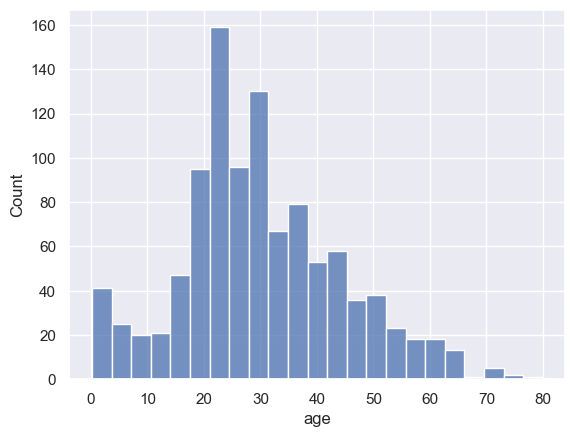

In [21]:
sns.histplot(df['age']);

Imputing missing numeric values: use mean is there is a standard distribution and median if the data is skewed

Imputing categorical values: use mode

In this case, mean = 30 and median = 28

In [22]:
df.loc[df.age.isnull(), 'age'] = 30
# df['age'] = df['age'].replace(np.nan, ??)

In [23]:
df.age.isnull().sum()

0

In [24]:
# how did this affect the column's statistics?
df.age.describe().T

count    1309.000000
mean       29.905019
std        12.883281
min         0.170000
25%        22.000000
50%        30.000000
75%        35.000000
max        80.000000
Name: age, dtype: float64

In [25]:
df['fare'].isnull().sum()

1

In [26]:
df[df['fare'].isnull()]

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
1225,3,0,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S,NaN,261.0,NaN


In [27]:
df.fare.describe().T

count    1308.000000
mean       33.295479
std        51.758668
min         0.000000
25%         7.895800
50%        14.454200
75%        31.275000
max       512.329200
Name: fare, dtype: float64

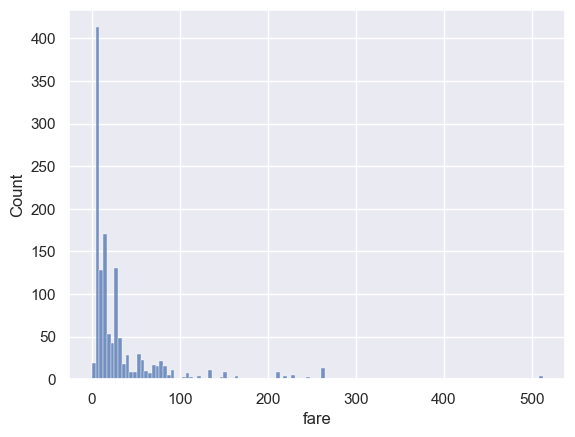

In [28]:
sns.histplot(df['fare']);

In [29]:
df.loc[df.fare.isnull(), 'fare'] = df.fare.median()
# df['fare'] = df['fare'].replace(np.nan, df.fare.median())

In [30]:
df.fare.describe().T

count    1309.000000
mean       33.281086
std        51.741500
min         0.000000
25%         7.895800
50%        14.454200
75%        31.275000
max       512.329200
Name: fare, dtype: float64

In [31]:
df['cabin'].isnull().sum()

1014

Over 75% of the rows do not have a value for the cabin column.  With that many columns missing, it is best to delete the column

In [32]:
df = df.drop(['cabin'], axis=1)

In [33]:
df.sample(10)

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,embarked,boat,body,home.dest
1302,3,0,"Yousif, Mr. Wazli",male,30.0,0,0,2647,7.2250,C,NaN,NaN,NaN
651,3,0,"Attalah, Mr. Sleiman",male,30.0,0,0,2694,7.2250,C,NaN,NaN,"Ottawa, ON"
864,3,0,"Henriksson, Miss. Jenny Lovisa",female,28.0,0,0,347086,7.7750,S,NaN,NaN,NaN
5,1,1,"Anderson, Mr. Harry",male,48.0,0,0,19952,26.5500,S,3,NaN,"New York, NY"
910,3,0,"Kallio, Mr. Nikolai Erland",male,17.0,0,0,STON/O 2. 3101274,7.1250,S,NaN,NaN,NaN
1145,3,0,"Rice, Master. George Hugh",male,8.0,4,1,382652,29.1250,Q,NaN,NaN,NaN
270,1,1,"Smith, Mrs. Lucien Philip (Mary Eloise Hughes)",female,18.0,1,0,13695,60.0000,S,6,NaN,"Huntington, WV"
90,1,1,"Davidson, Mrs. Thornton (Orian Hays)",female,27.0,1,2,F.C. 12750,52.0000,S,3,NaN,"Montreal, PQ"
1221,3,0,"Staneff, Mr. Ivan",male,30.0,0,0,349208,7.8958,S,NaN,NaN,NaN
373,2,1,"Clarke, Mrs. Charles V (Ada Maria Winfield)",female,28.0,1,0,2003,26.0000,S,14,NaN,"England / San Francisco, CA"


In [34]:
df['embarked'].isnull().sum()

2

In [35]:
df[df['embarked'].isnull()]

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,embarked,boat,body,home.dest
168,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,NaN,6,NaN,NaN
284,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,NaN,6,NaN,"Cincinatti, OH"


In [36]:
df['embarked'].mode()

0    S
Name: embarked, dtype: object

In [37]:
df['embarked'].value_counts()

embarked
S    914
C    270
Q    123
Name: count, dtype: int64

In [38]:
#df.loc[df.embarked.isnull(), 'age'] = 30
df['embarked'] = df['embarked'].replace(np.nan, 'S')

In [39]:
# verify there aren't any missing values
df.isnull().sum()

pclass          0
survived        0
name            0
sex             0
age             0
sibsp           0
parch           0
ticket          0
fare            0
embarked        0
boat          823
body         1188
home.dest     564
dtype: int64

#### Handle outliers

In [40]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
pclass,1309.0,2.294882,0.837836,1.00,2.0000,3.0000,3.000,3.0000
survived,1309.0,0.381971,0.486055,0.00,0.0000,0.0000,1.000,1.0000
age,1309.0,29.905019,12.883281,0.17,22.0000,30.0000,35.000,80.0000
sibsp,1309.0,0.498854,1.041658,0.00,0.0000,0.0000,1.000,8.0000
parch,1309.0,0.385027,0.865560,0.00,0.0000,0.0000,0.000,9.0000
fare,1309.0,33.281086,51.741500,0.00,7.8958,14.4542,31.275,512.3292
body,121.0,160.809917,97.696922,1.00,72.0000,155.0000,256.000,328.0000


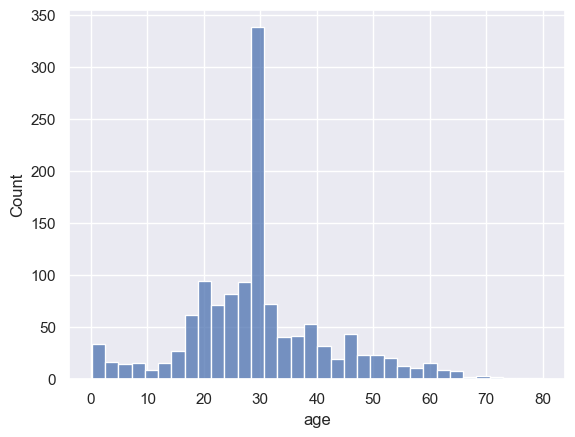

In [41]:
sns.histplot(df['age']);

In [42]:
df.fare.describe().T

count    1309.000000
mean       33.281086
std        51.741500
min         0.000000
25%         7.895800
50%        14.454200
75%        31.275000
max       512.329200
Name: fare, dtype: float64

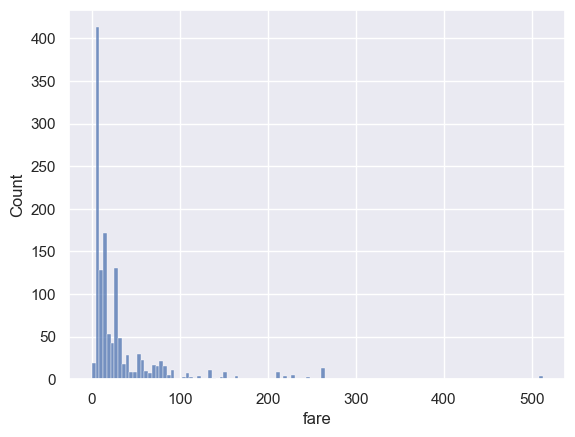

In [43]:
sns.histplot(df['fare']);

In [44]:
df[df['fare'] > 500]

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,embarked,boat,body,home.dest
49,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,C,3,NaN,"Austria-Hungary / Germantown, Philadelphia, PA"
50,1,1,"Cardeza, Mrs. James Warburton Martinez (Charlo...",female,58.0,0,1,PC 17755,512.3292,C,3,NaN,"Germantown, Philadelphia, PA"
183,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,C,3,NaN,NaN
302,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,C,3,NaN,NaN


In [45]:
df.groupby("pclass")["fare"].median()

pclass
1    60.0000
2    15.0458
3     8.0500
Name: fare, dtype: float64

In [46]:
# update the 51232.92 fare prices with the median fare price for pclass 1
df.loc[df['fare'] == 512.3292, ['fare']] = 60

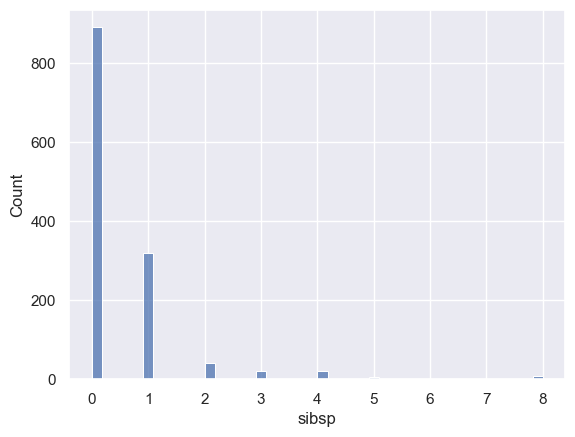

In [47]:
sns.histplot(df['sibsp']);

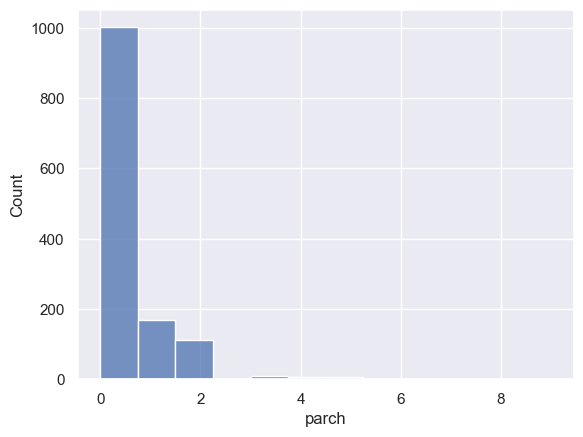

In [48]:
sns.histplot(df['parch']);

#### Check for inconsistent data in the  columns

In [49]:
df.dtypes

pclass         int64
survived       int64
name          object
sex           object
age          float64
sibsp          int64
parch          int64
ticket        object
fare         float64
embarked      object
boat          object
body         float64
home.dest     object
dtype: object

In [50]:
df['sex'].value_counts()

sex
male      843
female    466
Name: count, dtype: int64

In [51]:
# update 'fe male' values to 'female'
df.loc[df['sex'] == 'fe male', ['sex']] = 'female'

In [52]:
df['sex'].value_counts()

sex
male      843
female    466
Name: count, dtype: int64

In [53]:
df['embarked'].value_counts()

embarked
S    916
C    270
Q    123
Name: count, dtype: int64

In [54]:
df['sibsp'].value_counts()

sibsp
0    891
1    319
2     42
4     22
3     20
8      9
5      6
Name: count, dtype: int64

In [55]:
df['parch'].value_counts()

parch
0    1002
1     170
2     113
3       8
4       6
5       6
6       2
9       2
Name: count, dtype: int64

#### Delete columns that do not affect the prediction or target value

In [56]:
df.nunique()

pclass          3
survived        2
name         1307
sex             2
age            98
sibsp           7
parch           8
ticket        929
fare          280
embarked        3
boat           27
body          121
home.dest     369
dtype: int64

In [57]:
df.sample(20)

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,embarked,boat,body,home.dest
314,1,1,"Widener, Mrs. George Dunton (Eleanor Elkins)",female,50.0,1,1,113503,211.5000,C,4,NaN,"Elkins Park, PA"
834,3,0,"Gronnestad, Mr. Daniel Danielsen",male,32.0,0,0,8471,8.3625,S,NaN,NaN,"Foresvik, Norway Portland, ND"
456,2,0,"Howard, Mrs. Benjamin (Ellen Truelove Arman)",female,60.0,1,0,24065,26.0000,S,NaN,NaN,"Swindon, England"
363,2,0,"Campbell, Mr. William",male,30.0,0,0,239853,0.0000,S,NaN,NaN,Belfast
336,2,1,"Beane, Mr. Edward",male,32.0,1,0,2908,26.0000,S,13,NaN,"Norwich / New York, NY"
409,2,0,"Fox, Mr. Stanley Hubert",male,36.0,0,0,229236,13.0000,S,NaN,236.0,"Rochester, NY"
622,3,0,"Andersson, Master. Sigvard Harald Elias",male,4.0,4,2,347082,31.2750,S,NaN,NaN,"Sweden Winnipeg, MN"
921,3,0,"Keefe, Mr. Arthur",male,30.0,0,0,323592,7.2500,S,A,NaN,NaN
709,3,1,"Carr, Miss. Helen ""Ellen""",female,16.0,0,0,367231,7.7500,Q,16,NaN,"Co Longford, Ireland New York, NY"
538,2,1,"Portaluppi, Mr. Emilio Ilario Giuseppe",male,30.0,0,0,C.A. 34644,12.7375,C,14,NaN,"Milford, NH"


In [58]:
## name - all but two rows are unique values - at this point we will keep name because there are things that we  
#         may be able to draw out later - last name, title

In [59]:
## ticket - ticket number does not have an effect on our target number

In [60]:
df = df.drop(['ticket'], axis=1)

In [61]:
df.sample(20)

,pclass,survived,name,sex,age,sibsp,parch,fare,embarked,boat,body,home.dest
1126,3,0,"Petranec, Miss. Matilda",female,28.0,0,0,7.8958,S,NaN,NaN,NaN
156,1,0,"Head, Mr. Christopher",male,42.0,0,0,42.5000,S,NaN,NaN,London / Middlesex
260,1,1,"Shutes, Miss. Elizabeth W",female,40.0,0,0,153.4625,S,3,NaN,"New York, NY / Greenwich CT"
273,1,1,"Spedden, Master. Robert Douglas",male,6.0,0,2,134.5000,C,3,NaN,"Tuxedo Park, NY"
1185,3,0,"Samaan, Mr. Hanna",male,30.0,2,0,21.6792,C,NaN,NaN,NaN
289,1,1,"Taussig, Miss. Ruth",female,18.0,0,2,79.6500,S,8,NaN,"New York, NY"
1050,3,1,"Nakid, Mrs. Said (Waika ""Mary"" Mowad)",female,19.0,1,1,15.7417,C,C,NaN,NaN
1200,3,0,"Simmons, Mr. John",male,30.0,0,0,8.0500,S,NaN,NaN,NaN
179,1,0,"Klaber, Mr. Herman",male,30.0,0,0,26.5500,S,NaN,NaN,"Portland, OR"
846,3,0,"Hampe, Mr. Leon",male,20.0,0,0,9.5000,S,NaN,NaN,NaN


## Exploratory Data Analysis

<p style="font-size:14px; font-weight: 500;">Categorical Features:</p>
<ul>
    <li>pclass</li>
    <li>name</li>
    <li>sex</li>
    <li>embarked</li>
</ul>
<p style="font-size:14px; font-weight: 500;">Numerical Features:</p>
<ul>
    <li>age</li>
    <li>sibsp</li>
    <li>parch</li>
    <li>fare</li>
</ul>

### Univariate Analysis

#### Exploring Numeric Features: age, sibsp, parch, fare

In [62]:
df.age.describe()

count    1309.000000
mean       29.905019
std        12.883281
min         0.170000
25%        22.000000
50%        30.000000
75%        35.000000
max        80.000000
Name: age, dtype: float64

#### Question 1

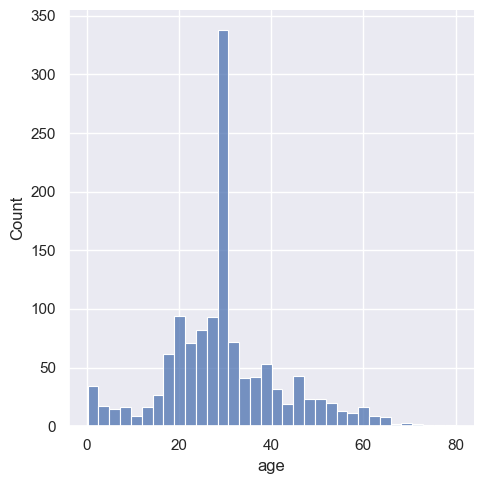

In [109]:
sns.displot(data=df,x='age',kde=False);

#### Question 2
The ends of the whisker represent the lower and upper fences for outliers. There are outliers on both ends of the chart.

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


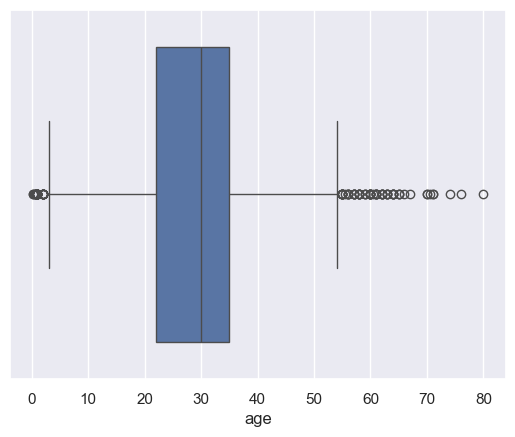

In [64]:
sns.boxplot(data=df,x='age');

In [65]:
df['age'].mode()

0    30.0
Name: age, dtype: float64

<p><b>Observations:</b></p>
<ul>
    <li>Age: Mean=29.9 Mode=30 Median=30 Range=0.17-80</li>
    <li>Data skewed right</li>
    <li>Median, Mean, Mode almost equal</li>
    <li>Many values outside of the upper and lower fences</li>
</ul>

In [66]:
df.sibsp.describe()

count    1309.000000
mean        0.498854
std         1.041658
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         8.000000
Name: sibsp, dtype: float64

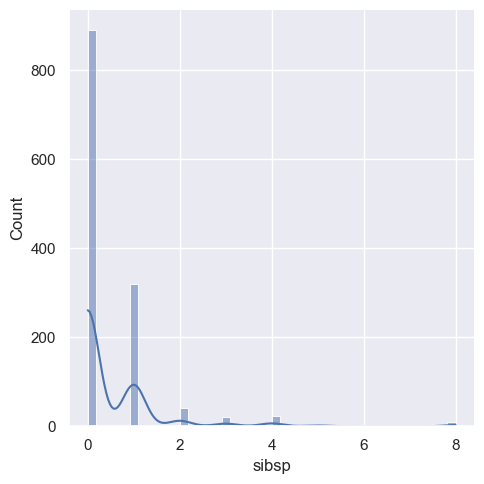

In [67]:
sns.displot(df['sibsp'], kde=True);

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


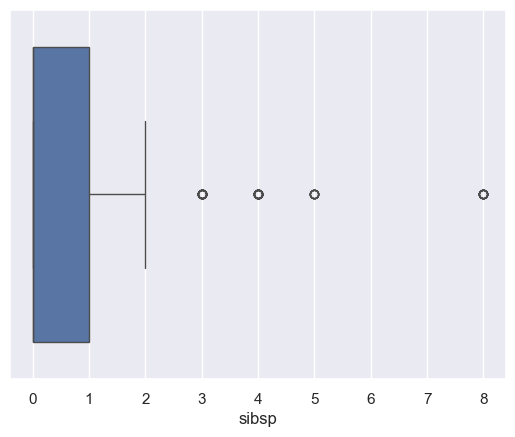

In [68]:
sns.boxplot(data=df, x='sibsp');

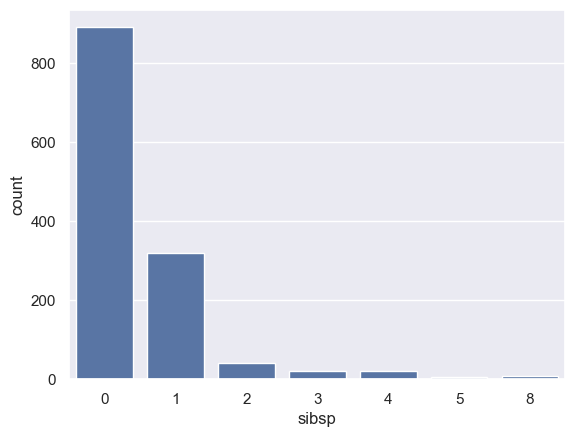

In [69]:
sns.countplot(data=df, x='sibsp');

<p><b>Observations:</b></p>
<ul>
    <li>sibsp: Mean=0.5 Mode=0 Median=0 Range=0-8</li>
    <li>Mean > Median</li>
    <li>Very skewed right</li>
    <li>Vast majority of passengers have no siblings</li>
    <li>=>3 siblings is considered outlier</li>
</ul>

In [70]:
df.parch.describe()

count    1309.000000
mean        0.385027
std         0.865560
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         9.000000
Name: parch, dtype: float64

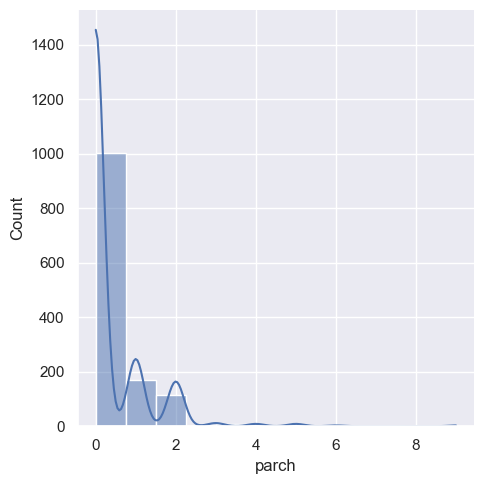

In [71]:
sns.displot(df['parch'], kde=True);

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


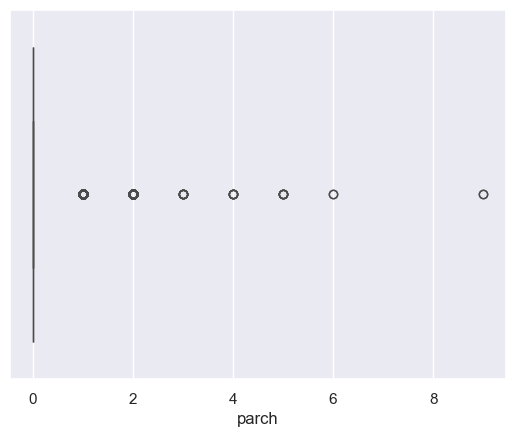

In [72]:
sns.boxplot(data=df, x='parch');

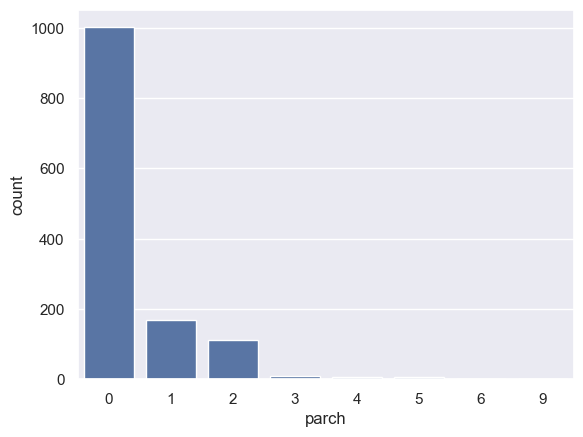

In [73]:
sns.countplot(data=df, x='parch');

<p><b>Observations:</b></p>
<ul>
    <li>parch: Mean=0.39 Mode=0 Median=0 Range=0-9</li>
    <li>Mean > Median</li>
    <li>Very skewed right</li>
    <li>Vast majority of passengers have no parents or children onboard</li>
    <li>Values => 1 is considered outlier</li>
</ul>

In [74]:
df.fare.describe()

count    1309.000000
mean       31.898873
std        44.448381
min         0.000000
25%         7.895800
50%        14.454200
75%        31.275000
max       263.000000
Name: fare, dtype: float64

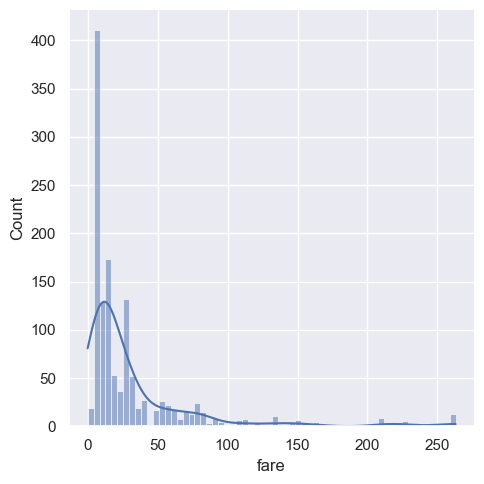

In [111]:
sns.displot(df['fare'], kde=True);

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


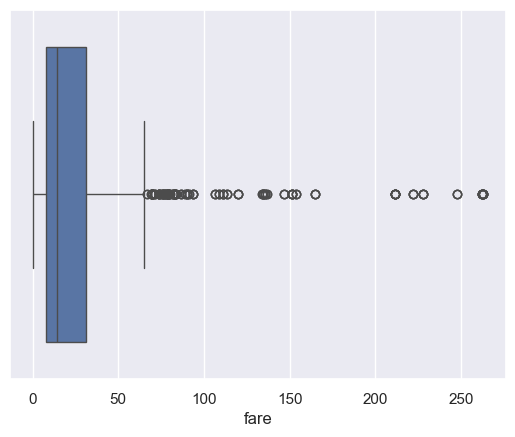

In [76]:
sns.boxplot(data=df, x='fare');

In [77]:
df.fare.mode()

0    8.05
Name: fare, dtype: float64

#### Question 9

<p><b>Observations:</b></p>
<ul>
    <li>Fare: Mean=31.9 Mode=8.05 Median=14.45 Range=0-263</li>
    <li>Mean > Median</li>
    <li>Very skewed right</li>
    <li>Wide range of values</li>
</ul>

#### Exploring Categorical Features: pclass, sex, embarked

(Name will be ignored until later)

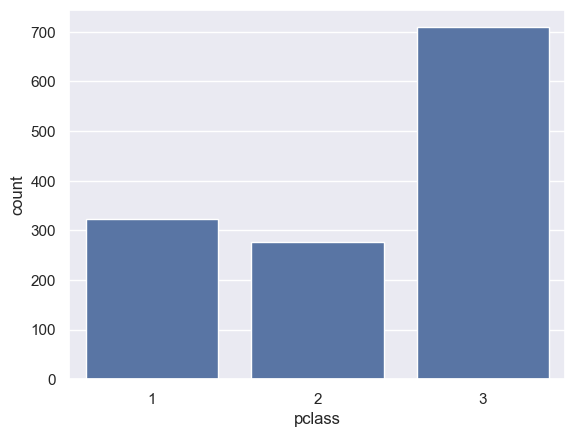

In [78]:
sns.countplot(data=df, x='pclass');

<p><b>Observation: </b>Class 3 is the most common, by far, followed by 1, then 2</p>

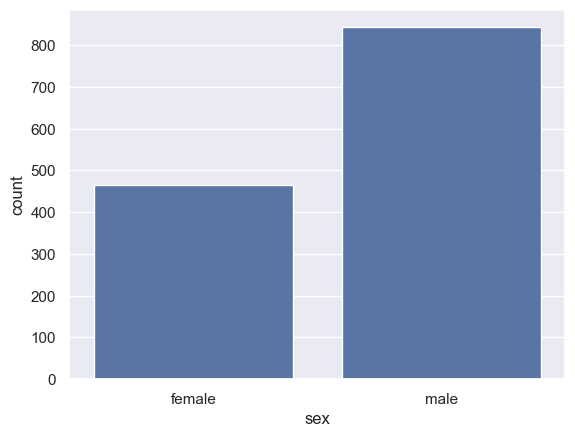

In [79]:
sns.countplot(data=df, x='sex');

<p><b>Observation:</b> There were almost twice as many male passengers as there were female</p>

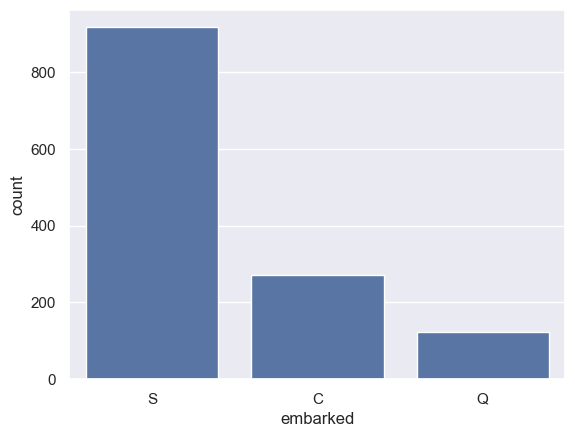

In [80]:
sns.countplot(data=df, x='embarked');

<p><b>Observation: </b>The vast majority of passengers embarked from Southampton, followed by those from Cherbourg, then Queenstown</p>

### Bivariate Analysis

#### Question 6

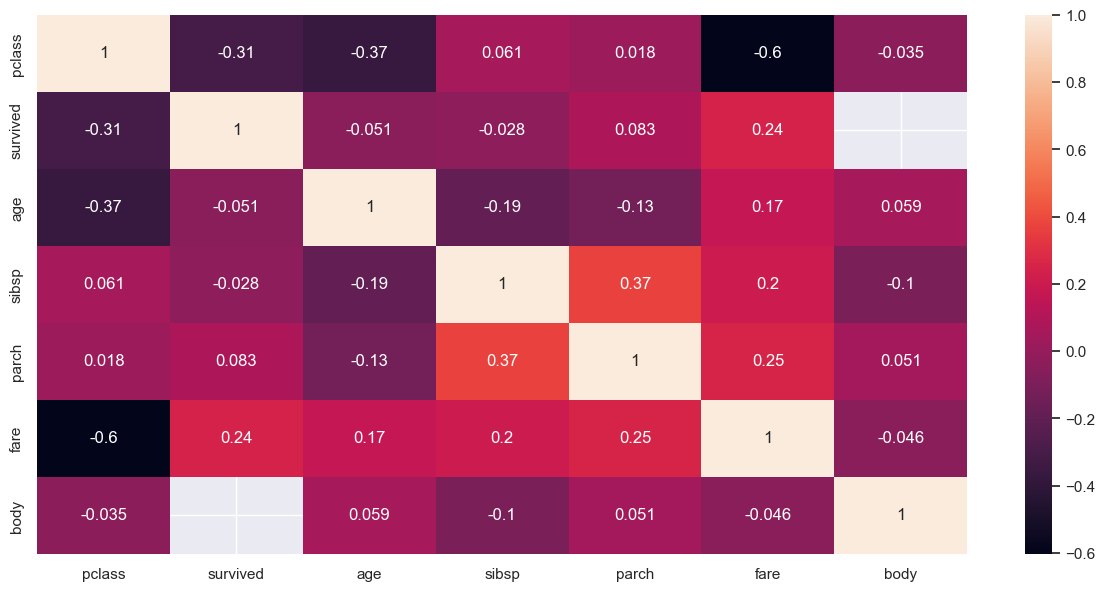

In [81]:
plt.figure(figsize=(15, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True);

<p><b>Observations:</b></p>
<ul>
    <li>Highest correlation to survival is fare</li>
    <li>Highest correlations overall are sibsp/parch & fare/parch</li>
    <li>Aside from sibsp/parch</li>
    <li>Age has negative correlation to survival, despite strong connection to fare</li>
    <li>Aside from fare, survival doesn't have a considerable correlation to any other field</li>
    <li>Lowest correlations overall are pclass/fare & pclass/age</li>
</ul>

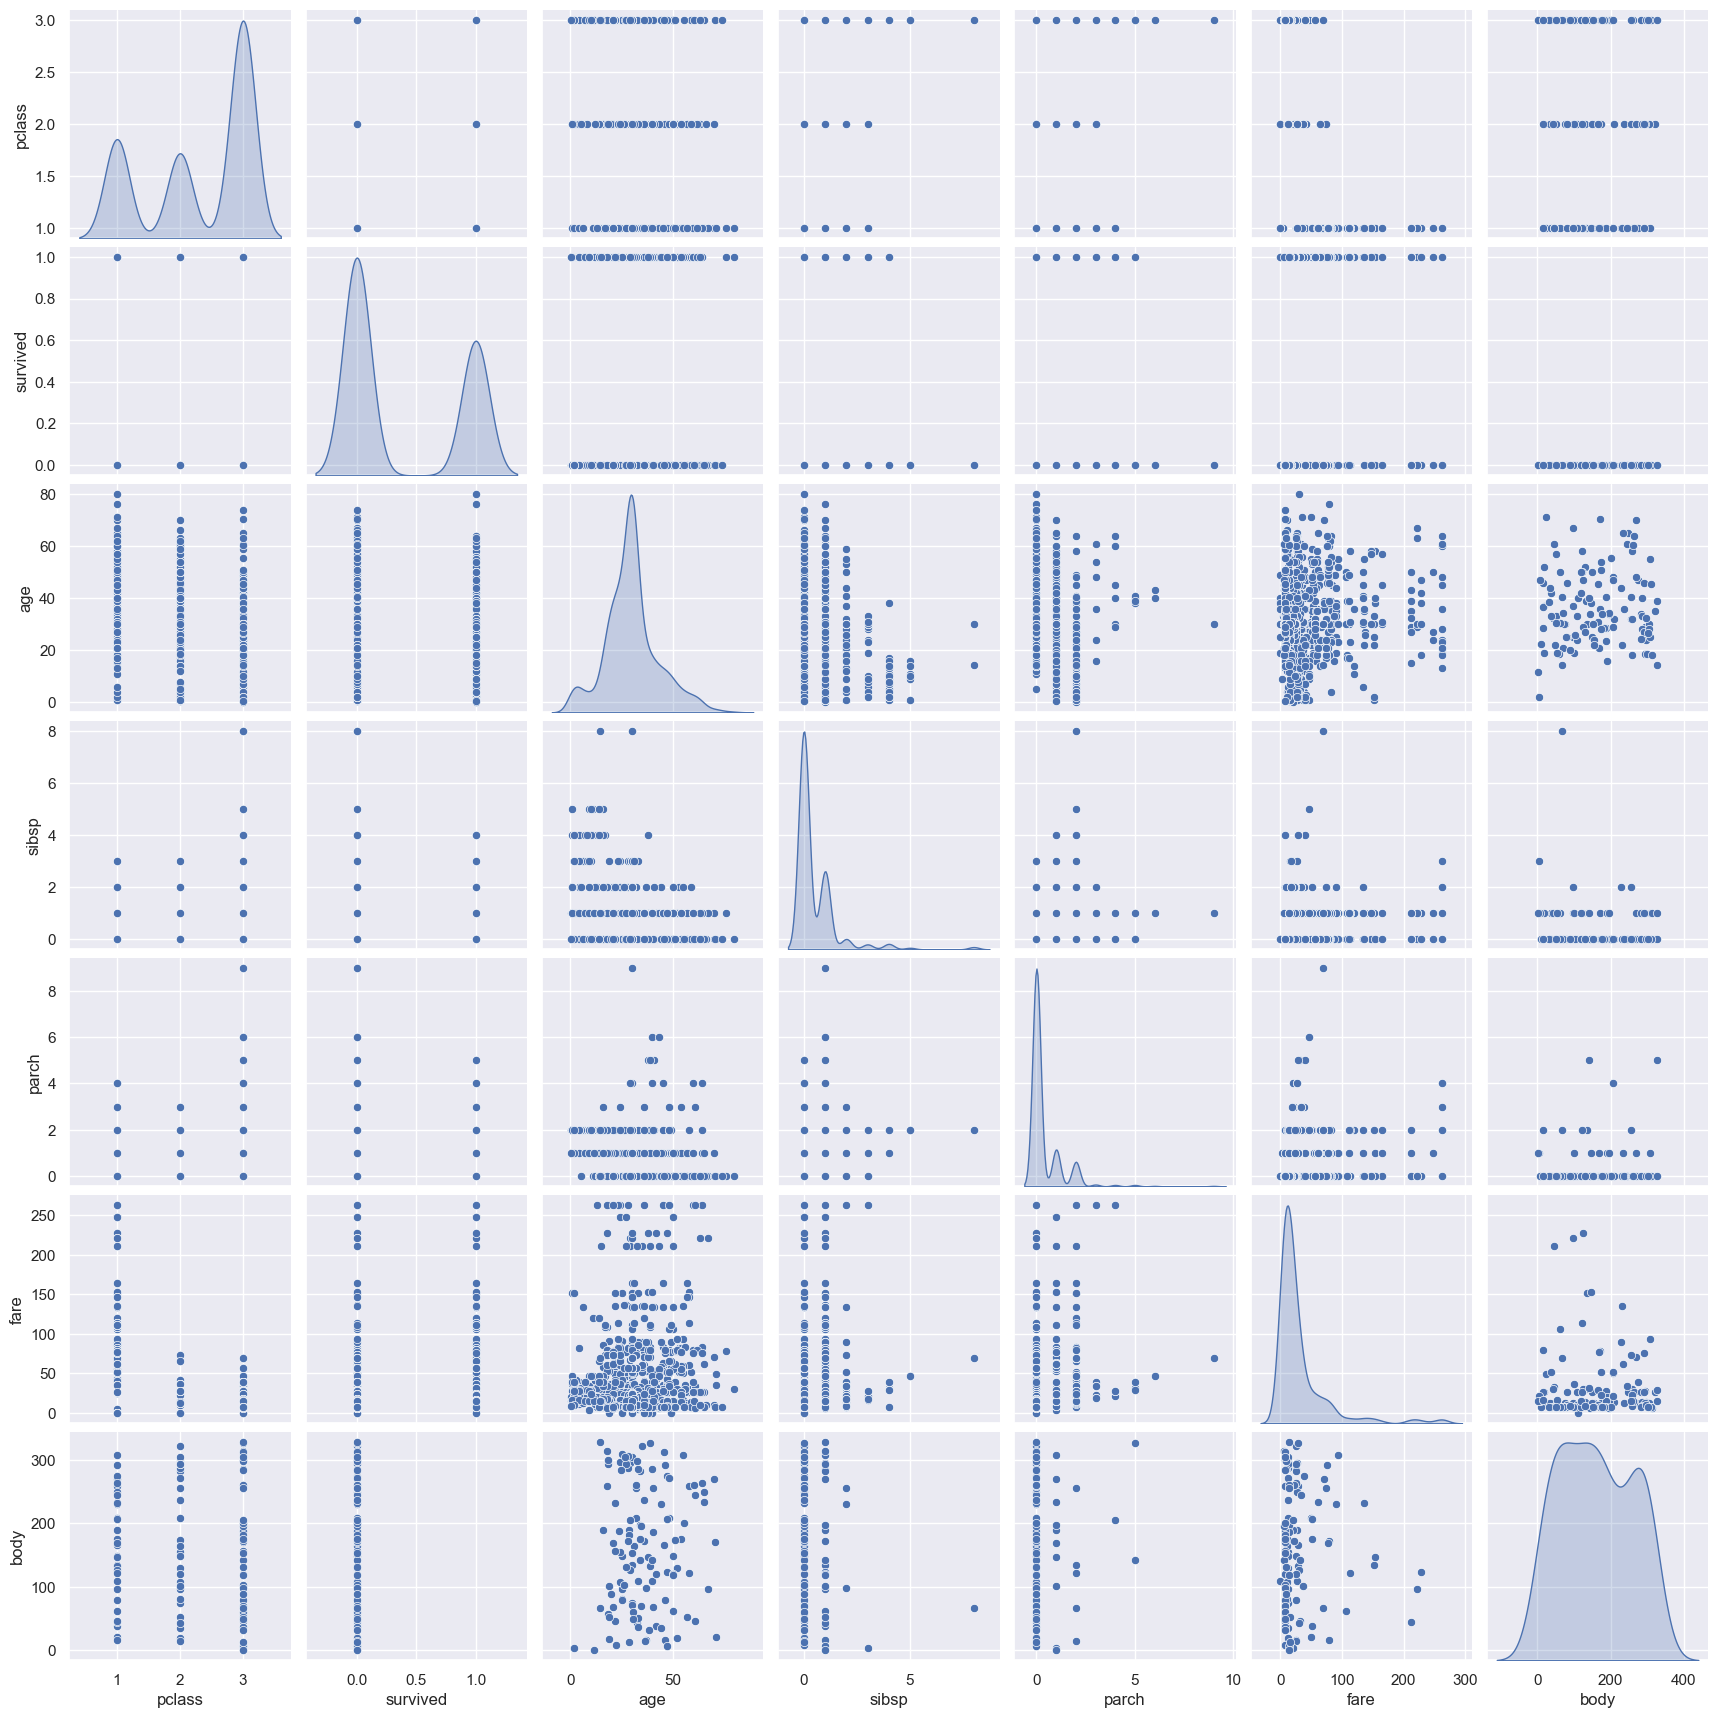

In [82]:
sns.pairplot(df, diag_kind="kde");

#### Mean values of numeric columns, based on survival

In [83]:
# Separating out columns to compare, then displaying their means compared to survival
grouped = df[['age', 'sibsp', 'parch', 'fare']]
grouped.groupby(df['survived']).mean()

,age,sibsp,parch,fare
survived,,,,
0,30.417281,0.521632,0.328801,23.34283
1,29.076180,0.462000,0.476000,45.74255


<p><b>Observations:</b></p>
<ul>
    <li>Limited differences in age and sibsp</li>
    <li>Slight difference in parch</li>
    <li>Largest difference in fare</li>
</ul>

#### Visualizing pclass correlation to survival

#### Question 4

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


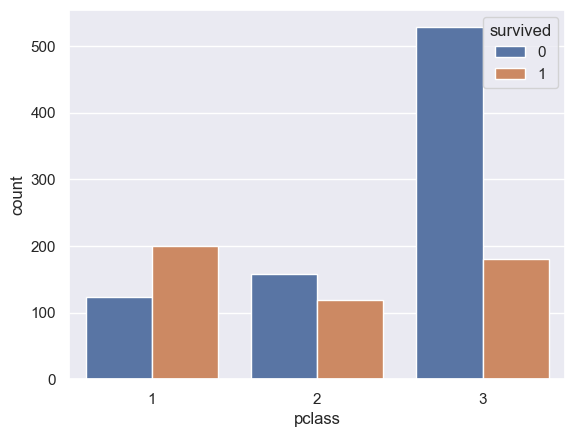

In [85]:
sns.countplot(data=df, hue='survived', x='pclass');

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.g

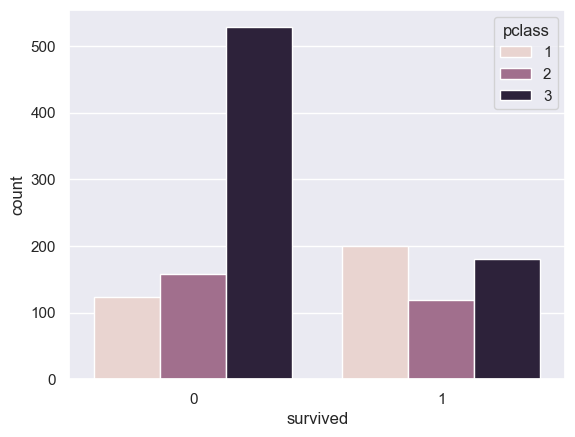

In [86]:
sns.countplot(data=df, hue='pclass', x='survived');

In [87]:
pd.crosstab(df['survived'], df['pclass'])

pclass,1,2,3
survived,,,
0,123,158,528
1,200,119,181


<p><b>Observations:</b></p>
<ul>
    <li>Those in class 3 had lowest survival percentage</li>
    <li>Those in class 2 were almost equally likely to survive or die</li>
    <li>Those in class 1 were more likely to survive than not</li>
</ul>

#### Visualizing sex correlation to survival

#### Question 5

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


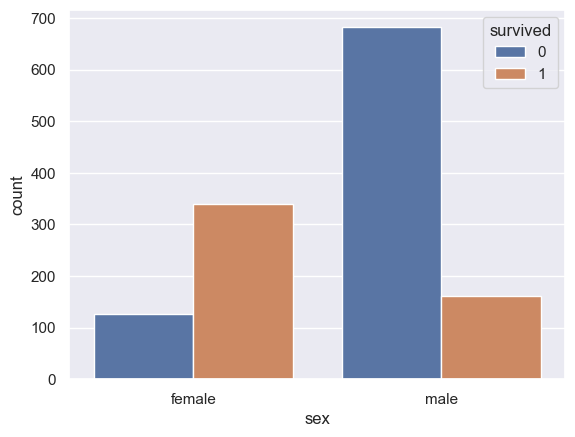

In [90]:
sns.countplot(data=df, hue='survived', x='sex');

In [93]:
pd.crosstab(df['survived'], df['sex'])

sex,female,male
survived,,
0,127,682
1,339,161


<p><b>Observation:</b></p>
<ul>
    <li>Females were significantly more likely to survive than males</li>
</ul>

#### Visualizing embarked correlation to survival

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


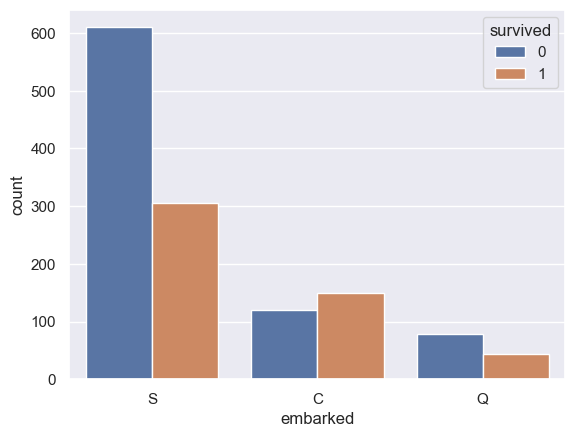

In [94]:
sns.countplot(data=df, hue='survived', x='embarked');

In [95]:
pd.crosstab(df['survived'], df['embarked'])

embarked,C,Q,S
survived,,,
0,120,79,610
1,150,44,306


<p><b>Observation:</b></p>
<ul>
    <li>Those embarking from Cherbourg were the only ones more likely to survive than not</li>
</ul>

#### Visualizing sibsp correlation to survival

Including sibsp with non-numerical visualization, due to small range of values

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


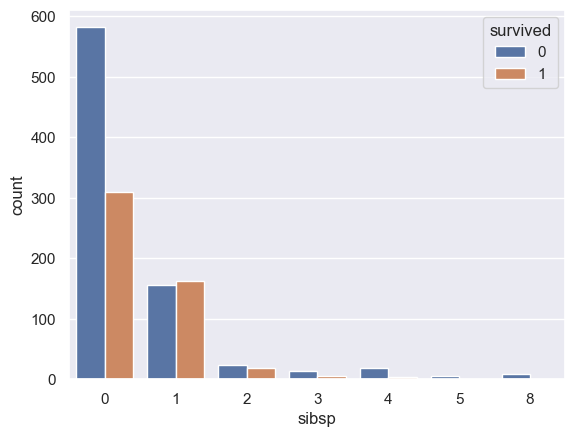

In [103]:
sns.countplot(data=df, hue='survived', x='sibsp');

In [104]:
pd.crosstab(df['survived'], df['sibsp'])

sibsp,0,1,2,3,4,5,8
survived,,,,,,,
0,582,156,23,14,19,6,9
1,309,163,19,6,3,0,0


<p><b>Observations:</b></p>
<ul>
    <li>The only possible correlation is that those without any siblings are less likely to survive</li>
    <li>Those with many siblings being attributed only to non-survival is misleading, as this could be from a low-fare/low-class family</li>
</ul>

#### Visualizing sibsp correlation to survival

Including sibsp with non-numerical visualization, due to small range of values

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


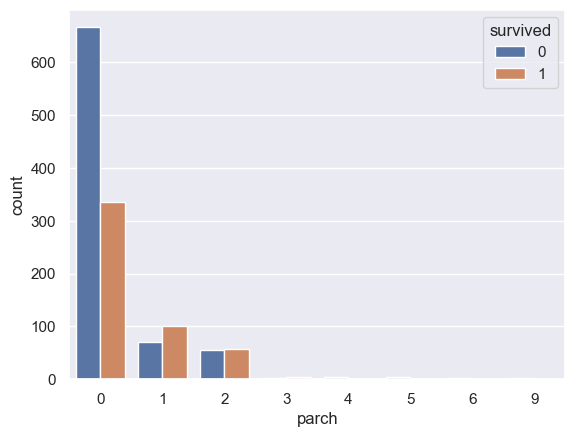

In [105]:
sns.countplot(data=df, hue='survived', x='parch');

In [106]:
pd.crosstab(df['survived'], df['parch'])

parch,0,1,2,3,4,5,6,9
survived,,,,,,,,
0,666,70,56,3,5,5,2,2
1,336,100,57,5,1,1,0,0


<p><b>Observation:</b></p>
<ul>
    <li>Only potential correlation is that those without parents/children onboard are less likely to live.</li>
    <li>This could be misleading, as those without parents/children could be less wealthy, on average</li>
</ul>

#### Visualizing correlation between survival and numeric columns

#### Question 7

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


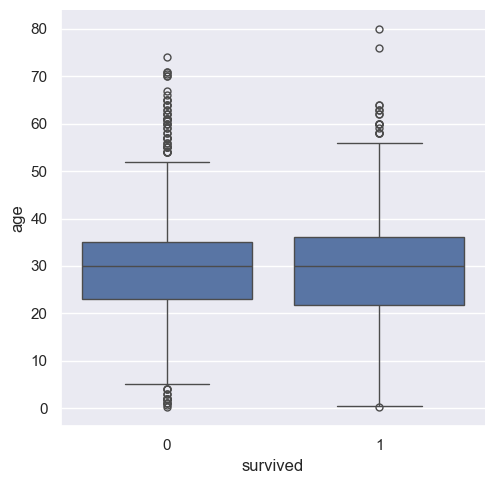

In [97]:
sns.catplot(data=df, x='survived', y='age', kind='box');

In [99]:
print(df.groupby(['survived']).age.mean(), df.groupby(['survived']).age.min(), df.groupby(['survived']).age.max())

survived
0    30.417281
1    29.076180
Name: age, dtype: float64 survived
0    0.33
1    0.17
Name: age, dtype: float64 survived
0    74.0
1    80.0
Name: age, dtype: float64


<p><b>Observation:</b></p>
<ul>
    <li>Age range for survivors is signficantly more narrow, aside from a few old outliers</li>
</ul>

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


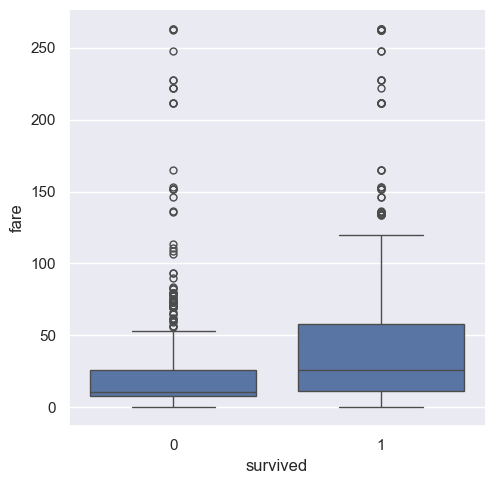

In [107]:
sns.catplot(data=df, x='survived', y='fare', kind='box');

In [108]:
print(df.groupby(['survived']).fare.mean(), df.groupby(['survived']).fare.min(), df.groupby(['survived']).fare.max())

survived
0    23.34283
1    45.74255
Name: fare, dtype: float64 survived
0    0.0
1    0.0
Name: fare, dtype: float64 survived
0    263.0
1    263.0
Name: fare, dtype: float64


<p><b>Observation:</b></p>
<ul>
    <li>Fare range for survivors is significantly wider than non-survivors</li>
</ul>

#### Question 8

C:\Users\codyd\AppData\Local\Temp\ipykernel_14300\3786648518.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.pointplot(data=df, x='pclass', y='fare', hue='survived', ci=None);
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


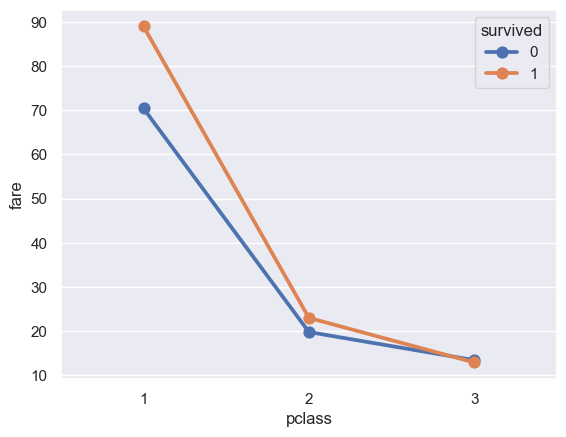

In [110]:
sns.pointplot(data=df, x='pclass', y='fare', hue='survived', ci=None);

<p><b>What combination do you think created the most informative chart?</b></p>
- This combination created the most informative chart